In [3]:
import torch
import torch.nn as nn
from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader

In [42]:
# Transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor()
])

In [43]:
import os
import random
import shutil

In [44]:
SOURCE_DIR = "../data/labelled"
TARGET_DIR = "../dataset"

SPLIT_RATIO = 0.8  # 80% train, 20% val

# needed to be this complicated, because on Mac system is looking for a .DS_Store file
classes = [d for d in os.listdir(SOURCE_DIR)
           if os.path.isdir(os.path.join(SOURCE_DIR, d))]

for cls in classes:
    cls_path = os.path.join(SOURCE_DIR, cls)
    images = [f for f in os.listdir(cls_path)
          if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    
    random.shuffle(images)
    
    split_idx = int(len(images) * SPLIT_RATIO)
    train_images = images[:split_idx]
    val_images = images[split_idx:]
    
    # Create folders
    os.makedirs(os.path.join(TARGET_DIR, "train", cls), exist_ok=True)
    os.makedirs(os.path.join(TARGET_DIR, "val", cls), exist_ok=True)
    
    # Copy files
    for img in train_images:
        shutil.copy(os.path.join(cls_path, img),
                    os.path.join(TARGET_DIR, "train", cls, img))
    
    for img in val_images:
        shutil.copy(os.path.join(cls_path, img),
                    os.path.join(TARGET_DIR, "val", cls, img))

print("Done.")

Done.


In [51]:
# Dataset
train_data = datasets.ImageFolder("../dataset/train", transform=transform)
val_data = datasets.ImageFolder("../dataset/val", transform=transform)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32)


In [52]:
# Model
model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 6)

In [53]:
# Freeze backbone
for param in model.parameters():
    param.requires_grad = False

for param in model.fc.parameters():
    param.requires_grad = True

In [54]:
# Training setup
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-3)

In [56]:
# For the visualization of training/validation loss/accuracy
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

In [57]:
# Training
import datetime

timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M")
filename = f"../models/best_model_{timestamp}.pth"

best_val_acc = 0.0
best_epoch = 0

def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / total
    accuracy = correct / total

    return avg_loss, accuracy


for epoch in range(10):
    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    val_loss, val_acc = evaluate(model, val_loader, criterion)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}:")
    print(f"  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"  Val   Loss: {val_loss:.4f}, Val   Acc: {val_acc:.4f}")
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch + 1

        torch.save({
            'epoch': best_epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': best_val_acc,
            'classes': train_data.classes
        }, filename)

        print(f"✅ Best model saved at epoch {best_epoch} with val_acc={best_val_acc:.4f}")

Epoch 1:
  Train Loss: 0.3126, Train Acc: 0.9720
  Val   Loss: 0.2823, Val   Acc: 0.9626
✅ Best model saved at epoch 1 with val_acc=0.9626
Epoch 2:
  Train Loss: 0.2480, Train Acc: 0.9720
  Val   Loss: 0.2555, Val   Acc: 0.9720
✅ Best model saved at epoch 2 with val_acc=0.9720
Epoch 3:
  Train Loss: 0.2346, Train Acc: 0.9790
  Val   Loss: 0.2403, Val   Acc: 0.9720
Epoch 4:
  Train Loss: 0.2314, Train Acc: 0.9790
  Val   Loss: 0.2095, Val   Acc: 0.9907
✅ Best model saved at epoch 4 with val_acc=0.9907
Epoch 5:
  Train Loss: 0.2136, Train Acc: 0.9790
  Val   Loss: 0.1876, Val   Acc: 0.9907
Epoch 6:
  Train Loss: 0.2093, Train Acc: 0.9720
  Val   Loss: 0.1944, Val   Acc: 0.9813
Epoch 7:
  Train Loss: 0.2018, Train Acc: 0.9685
  Val   Loss: 0.1823, Val   Acc: 0.9907
Epoch 8:
  Train Loss: 0.1675, Train Acc: 0.9825
  Val   Loss: 0.1598, Val   Acc: 0.9907
Epoch 9:
  Train Loss: 0.1537, Train Acc: 0.9860
  Val   Loss: 0.1622, Val   Acc: 0.9813
Epoch 10:
  Train Loss: 0.1490, Train Acc: 0.9895

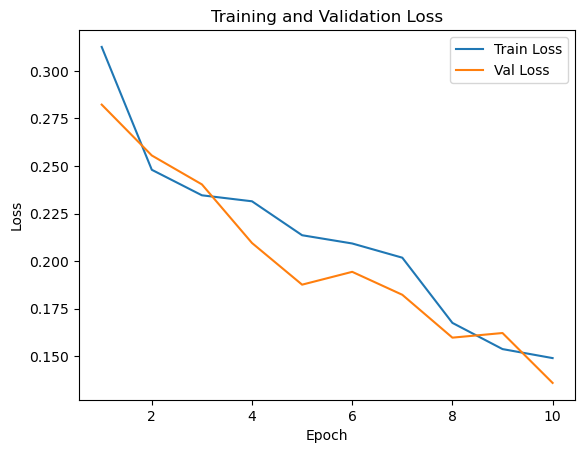

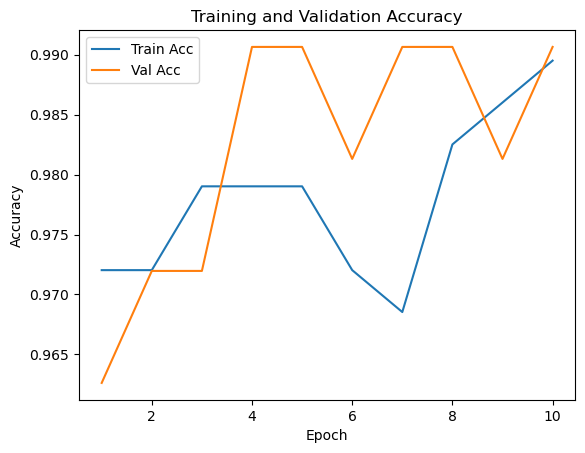

In [58]:
# Visualize the training
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

# Loss plot
plt.figure()
plt.plot(epochs, train_losses)
plt.plot(epochs, val_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend(["Train Loss", "Val Loss"])
plt.show()

# Accuracy plot
plt.figure()
plt.plot(epochs, train_accuracies)
plt.plot(epochs, val_accuracies)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend(["Train Acc", "Val Acc"])
plt.show()

In [59]:
#Collect predictions

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [60]:
from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(all_labels, all_preds)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

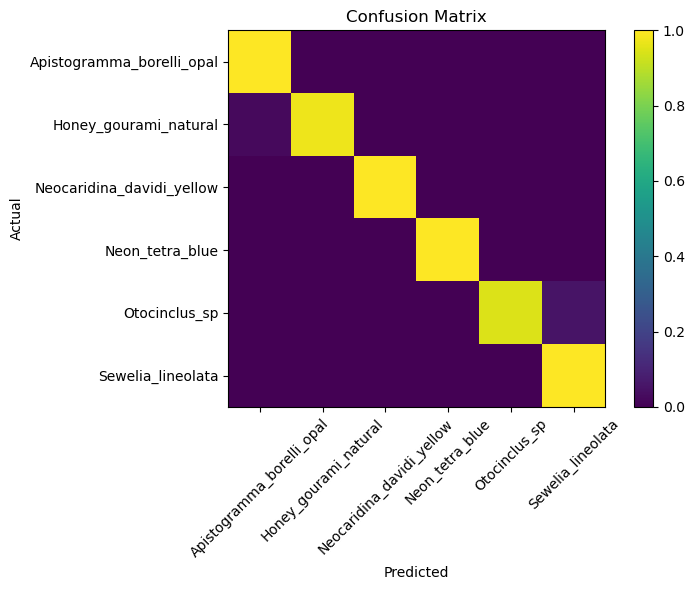

In [61]:
import matplotlib.pyplot as plt
import numpy as np

classes = train_data.classes

plt.figure(figsize=(8, 6))
plt.imshow(cm_normalized, interpolation='nearest')
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

In [41]:
class_accuracy = cm.diagonal() / cm.sum(axis=1)

for i, acc in enumerate(class_accuracy):
    print(f"{classes[i]}: {acc:.2f}")

Apistogramma_borelli_opal: 0.70
Honey_gourami_natural: 1.00
Neocaridina_davidi_yellow: 0.75
Neon_tetra_blue: 1.00
Otocinclus_sp: 0.92
Sewelia_lineolata: 1.00
